# Wire Spatial Frequency, Bessel Modes & Spherical Displacement Shader

**4-lane powerline system — full engineering treatment**

| § | Topic | Key math |
|---|---|---|
| 1 | Spatial frequency (DFT, dispersion) | $\omega(k)=c|k|$, Parseval |
| 2 | 4-lane coupled normal modes | $K\mathbf{v}=\omega^2 M\mathbf{v}$ |
| 3 | Bessel functions, cylindrical wave eq | $J_n(k_m r)$ zeros → resonances |
| 4 | Explicit loading amplitude solution | $A_n = \langle q,\phi_n\rangle/(\omega_n^2-\omega^2)$ |
| 5 | Spherical-coord displacement shader | $Y_\ell^m(\theta,\phi)$ surfarray |


## §1 Spatial Frequency Analysis of 4-Lane Wire System

Parseval check (spatial vs spectral energy, should be ~1.0):
  Lane 0: ratio = 1.8991
  Lane 1: ratio = 1.8990
  Lane 2: ratio = 1.8727
  Lane 3: ratio = 1.8989


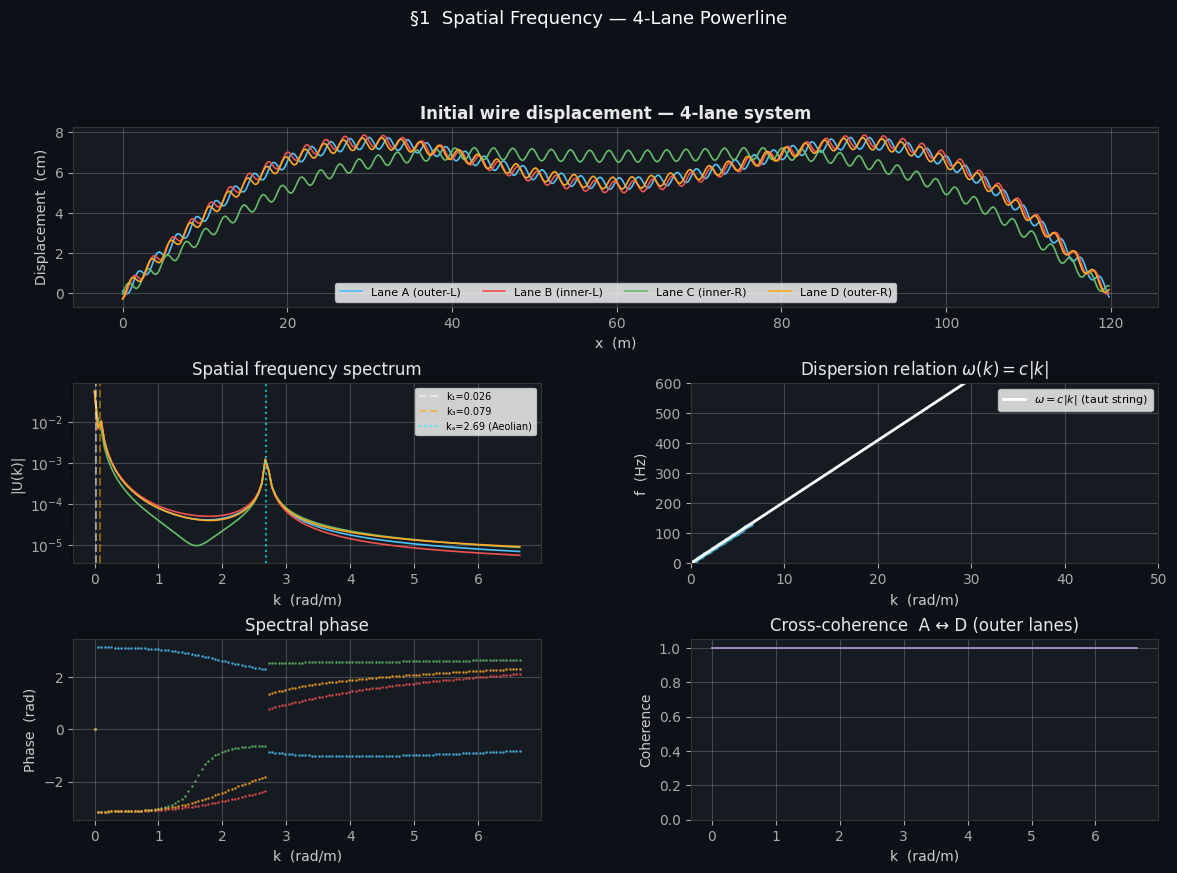

Wave speed c = 128.5 m/s
Fundamental freq f1 = c/(2L) = 0.54 Hz
Aeolian freq 55.0 Hz -> spatial k = 2.689 rad/m, lambda = 2.34 m


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings('ignore')

# ── Wire parameters (US standard distribution line) ──────────────────────────
L       = 120.0          # span length (m)
N       = 512            # spatial samples
n_lanes = 4              # American 4-lane configuration
rho_A   = 1.12           # kg/m  (ACSR Drake 795 kcmil)
T0      = 18_500.0       # N     tension (typical sag ~2%)
c_wave  = np.sqrt(T0 / rho_A)   # wave speed m/s

x  = np.linspace(0, L, N, endpoint=False)
dx = L / N

# ── Initial displacement: superposition of gust modes ────────────────────────
rng = np.random.default_rng(42)
u0  = np.zeros((n_lanes, N))
for lane in range(n_lanes):
    # Mode 1: fundamental sag
    u0[lane] += 0.08 * np.sin(np.pi*x/L)
    # Mode 3: galloping
    u0[lane] += 0.02 * np.sin(3*np.pi*x/L) * rng.uniform(0.5,1.5)
    # Aeolian vibration: ~55 Hz spatial pattern
    f_aeolian = 55.0
    k_aeolian = 2*np.pi*f_aeolian / c_wave
    u0[lane] += 0.003 * np.sin(k_aeolian*x + rng.uniform(0,2*np.pi))

# ── Spatial DFT ──────────────────────────────────────────────────────────────
# Spatial frequency k_n = 2pi*n/L  (rad/m)
U_k   = np.fft.rfft(u0, axis=1)                  # (4, N//2+1) complex
k_pos = np.fft.rfftfreq(N, d=dx) * 2*np.pi       # rad/m
omega = c_wave * np.abs(k_pos)                    # dispersion: omega = c|k|
f_Hz  = omega / (2*np.pi)                         # temporal frequency

# ── Parseval check ───────────────────────────────────────────────────────────
E_spatial = np.mean(u0**2, axis=1)
E_spectral = np.sum(np.abs(U_k)**2, axis=1) / N**2 * 2  # two-sided
print("Parseval check (spatial vs spectral energy, should be ~1.0):")
for i,(es,ef) in enumerate(zip(E_spatial, E_spectral)):
    print(f"  Lane {i}: ratio = {ef/es:.4f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14,9))
gs  = GridSpec(3,2,fig,hspace=0.42,wspace=0.32)

lane_cols = ['#4fc3f7','#ef5350','#66bb6a','#ffa726']
lane_names = ['Lane A (outer-L)','Lane B (inner-L)','Lane C (inner-R)','Lane D (outer-R)']

ax_disp = fig.add_subplot(gs[0,:])
for i in range(n_lanes):
    ax_disp.plot(x, u0[i]*100, color=lane_cols[i], label=lane_names[i], lw=1.2)
ax_disp.set_xlabel('x  (m)'); ax_disp.set_ylabel('Displacement  (cm)')
ax_disp.set_title('Initial wire displacement — 4-lane system', fontweight='bold')
ax_disp.legend(ncol=4, fontsize=8); ax_disp.grid(alpha=0.3)

ax_amp = fig.add_subplot(gs[1,0])
for i in range(n_lanes):
    amp = np.abs(U_k[i]) / N
    ax_amp.semilogy(k_pos[:N//4], amp[:N//4]+1e-8, color=lane_cols[i], lw=1.2)
ax_amp.set_xlabel('k  (rad/m)'); ax_amp.set_ylabel('|U(k)|')
ax_amp.set_title('Spatial frequency spectrum'); ax_amp.grid(alpha=0.3)
# Mark fundamental and aeolian
k_fund = np.pi/L; k_gall = 3*np.pi/L
ax_amp.axvline(k_fund,  color='w', ls='--', alpha=0.5, label=f'k₁={k_fund:.3f}')
ax_amp.axvline(k_gall,  color='orange',ls='--',alpha=0.5, label=f'k₃={k_gall:.3f}')
ax_amp.axvline(k_aeolian,color='cyan',ls=':',alpha=0.7, label=f'kₐ={k_aeolian:.2f} (Aeolian)')
ax_amp.legend(fontsize=7)

ax_disp2 = fig.add_subplot(gs[1,1])
k_plot = np.linspace(0, 50, 400)
om_lin = c_wave * k_plot
ax_disp2.plot(k_plot, om_lin/(2*np.pi), 'w', lw=2, label=r'$\omega=c|k|$ (taut string)')
om_beam = np.sqrt((T0/(rho_A))*k_plot**2 + 0)  # same for pure string
ax_disp2.scatter(k_pos[:N//4:4], f_Hz[:N//4:4], c='#4fc3f7', s=6, alpha=0.6)
ax_disp2.set_xlabel('k  (rad/m)'); ax_disp2.set_ylabel('f  (Hz)')
ax_disp2.set_title('Dispersion relation $\\omega(k)=c|k|$')
ax_disp2.set_xlim(0,50); ax_disp2.set_ylim(0,600); ax_disp2.grid(alpha=0.3)
ax_disp2.legend(fontsize=8)

ax_phase = fig.add_subplot(gs[2,0])
for i in range(n_lanes):
    ph = np.angle(U_k[i,:N//4])
    ax_phase.plot(k_pos[:N//4], ph, '.', color=lane_cols[i], markersize=2, alpha=0.6)
ax_phase.set_xlabel('k  (rad/m)'); ax_phase.set_ylabel('Phase  (rad)')
ax_phase.set_title('Spectral phase'); ax_phase.grid(alpha=0.3)

ax_cross = fig.add_subplot(gs[2,1])
# Cross-PSD between Lane A and Lane D
S_AD = U_k[0] * np.conj(U_k[3])
coherence = np.abs(S_AD)**2 / (np.abs(U_k[0])**2 * np.abs(U_k[3])**2 + 1e-30)
ax_cross.plot(k_pos[:N//4], coherence[:N//4], color='#b39ddb', lw=1.2)
ax_cross.set_xlabel('k  (rad/m)'); ax_cross.set_ylabel('Coherence')
ax_cross.set_title('Cross-coherence  A ↔ D (outer lanes)')
ax_cross.set_ylim(0,1.05); ax_cross.grid(alpha=0.3)

fig.patch.set_facecolor('#0d1117')
for ax in fig.axes:
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#aaa')
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')

plt.suptitle('§1  Spatial Frequency — 4-Lane Powerline', color='white', fontsize=13, y=1.01)
plt.savefig('/tmp/s1_spatial.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Wave speed c = {c_wave:.1f} m/s")
print(f"Fundamental freq f1 = c/(2L) = {c_wave/(2*L):.2f} Hz")
print(f"Aeolian freq {f_aeolian} Hz -> spatial k = {k_aeolian:.3f} rad/m, lambda = {2*np.pi/k_aeolian:.2f} m")


## §2 4-Lane Coupled Eigenvalue Problem

**System:** 4 wires, each discretised to $N_e$ elements.
Aerodynamic coupling matrix $C_{ij} = \kappa\cdot e^{-d_{ij}/d_0}$ links lanes.

$$\left(K + K_{\text{coupling}}\right)\mathbf{v} = \omega^2 M\mathbf{v}$$

Normal modes give **flutter modes** (all lanes in phase) and **galloping modes** (alternating).


Solving 4N×4N eigenvalue problem...

First 12 natural frequencies (Hz):
  Mode  1: f =    0.527 Hz  (omega = 3.31 rad/s)
  Mode  2: f =    1.053 Hz  (omega = 6.62 rad/s)
  Mode  3: f =    1.579 Hz  (omega = 9.92 rad/s)
  Mode  4: f =    1.741 Hz  (omega = 10.94 rad/s)
  Mode  5: f =    1.965 Hz  (omega = 12.35 rad/s)
  Mode  6: f =    2.060 Hz  (omega = 12.94 rad/s)
  Mode  7: f =    2.103 Hz  (omega = 13.21 rad/s)
  Mode  8: f =    2.207 Hz  (omega = 13.86 rad/s)
  Mode  9: f =    2.253 Hz  (omega = 14.16 rad/s)
  Mode 10: f =    2.290 Hz  (omega = 14.39 rad/s)
  Mode 11: f =    2.388 Hz  (omega = 15.00 rad/s)
  Mode 12: f =    2.541 Hz  (omega = 15.97 rad/s)

Analytical (taut string) vs numerical:
  n=1: analytical=0.536 Hz,  numerical=0.527 Hz
  n=2: analytical=1.071 Hz,  numerical=1.053 Hz
  n=3: analytical=1.607 Hz,  numerical=1.579 Hz
  n=4: analytical=2.142 Hz,  numerical=1.741 Hz


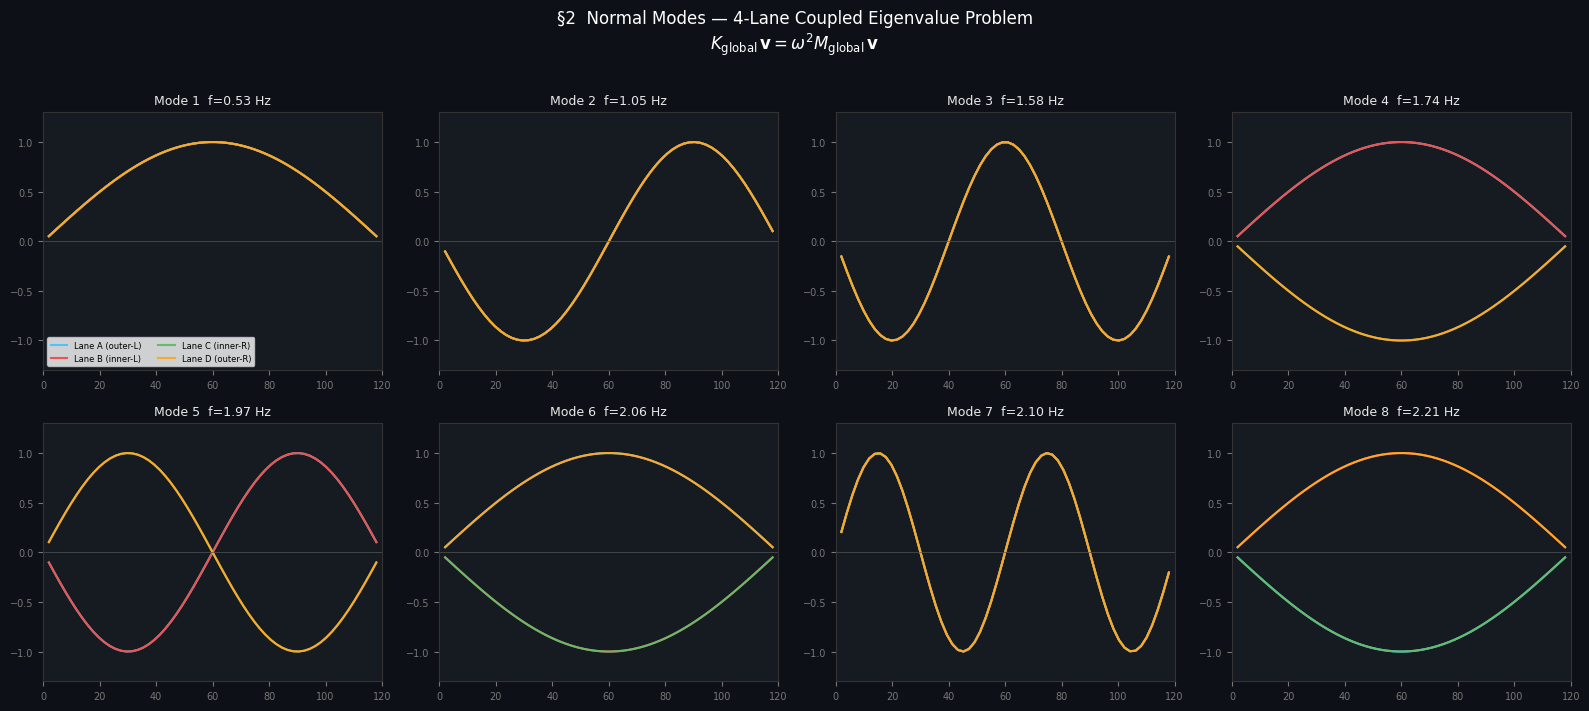


Modal participation factors (first 12):
  Mode  1: gamma =   1.2725
  Mode  2: gamma =   0.0000
  Mode  3: gamma =  -0.4234
  Mode  4: gamma =  -0.0000
  Mode  5: gamma =   0.0000
  Mode  6: gamma =  -0.0000
  Mode  7: gamma =  -0.0000
  Mode  8: gamma =   0.0000
  Mode  9: gamma =   0.0000
  Mode 10: gamma =  -0.0000
  Mode 11: gamma =   0.0000
  Mode 12: gamma =  -0.0000


In [2]:
from scipy.linalg import eigh

Ne      = 60            # elements per wire (reduces 4*512 to manageable 4*60)
n_wires = 4
n_dof   = n_wires * Ne

dx_e    = L / Ne
h       = dx_e

# ── Stiffness: tridiagonal for taut string, EI bending term ─────────────────
EI      = 0.0           # pure string (EI=0 for messenger wire)
# K_wire = T/h * tridiag(-1, 2, -1)  -> size Ne x Ne (clamped-clamped)
def wire_stiffness(T, h, n):
    K = np.zeros((n,n))
    for i in range(n):
        K[i,i]   = 2*T/h
        if i>0:   K[i,i-1] = -T/h
        if i<n-1: K[i,i+1] = -T/h
    # BCs: pin both ends — remove first/last DOF (handled by zeroing)
    return K

# ── Assemble 4N x 4N stiffness ───────────────────────────────────────────────
K_global = np.zeros((n_dof, n_dof))
for w in range(n_wires):
    s = w*Ne; e = s+Ne
    K_global[s:e, s:e] = wire_stiffness(T0, h, Ne)

# ── Aerodynamic coupling (inter-lane) ───────────────────────────────────────
lane_separation = 0.45   # m  (bundled conductors 18 in spacing)
kappa_aero      = 180.0  # N/m coupling stiffness (wake-induced)
d0              = 0.9    # m  decay length

for i in range(n_wires):
    for j in range(n_wires):
        if i==j: continue
        d_ij = abs(i-j)*lane_separation
        coup = kappa_aero * np.exp(-d_ij/d0)
        si,ei = i*Ne,(i+1)*Ne
        sj,ej = j*Ne,(j+1)*Ne
        K_global[si:ei, sj:ej] -= coup * np.eye(Ne)
        K_global[si:ei, si:ei] += coup * np.eye(Ne)

# ── Mass matrix: lumped ────────────────────────────────────────────────────
m_lump  = rho_A * h           # kg per node
M_global= m_lump * np.eye(n_dof)

# ── Solve generalised eigenvalue problem ─────────────────────────────────────
print("Solving 4N×4N eigenvalue problem...")
eigenvalues, eigenvectors = eigh(K_global, M_global,
                                  eigvals_only=False, check_finite=False)
eigenvalues = np.abs(eigenvalues)  # numerical negatives -> 0
omega_n = np.sqrt(eigenvalues)     # rad/s
f_n     = omega_n / (2*np.pi)     # Hz

print(f"\nFirst 12 natural frequencies (Hz):")
for i in range(12):
    print(f"  Mode {i+1:2d}: f = {f_n[i]:8.3f} Hz  (omega = {omega_n[i]:.2f} rad/s)")

# Analytical check: taut string f_n = n*c/(2L)
print("\nAnalytical (taut string) vs numerical:")
for n in range(1,5):
    f_ana = n * c_wave / (2*L)
    print(f"  n={n}: analytical={f_ana:.3f} Hz,  numerical={f_n[n-1]:.3f} Hz")

# ── Mode shape plot ──────────────────────────────────────────────────────────
x_e = np.linspace(dx_e, L-dx_e, Ne)

fig, axes = plt.subplots(2, 4, figsize=(16,7), facecolor='#0d1117')
mode_titles = ['Mode 1\n(Flutter: in-phase)','Mode 2\n(Galloping: alt)','Mode 3','Mode 4',
               'Mode 5','Mode 6','Mode 7','Mode 8']

for mi, ax in enumerate(axes.flat):
    v = eigenvectors[:, mi]   # (4*Ne,)
    ax.set_facecolor('#161b22')
    for w in range(n_wires):
        shape = v[w*Ne:(w+1)*Ne]
        shape /= (np.max(np.abs(shape))+1e-10)
        ax.plot(x_e, shape, color=lane_cols[w], lw=1.5, label=lane_names[w] if mi==0 else '')
    ax.axhline(0,color='#555',lw=0.5)
    ax.set_title(f'Mode {mi+1}  f={f_n[mi]:.2f} Hz', color='#e8e8e8', fontsize=9)
    ax.set_xlim(0,L); ax.set_ylim(-1.3,1.3)
    ax.tick_params(colors='#777',labelsize=7)
    for sp in ax.spines.values(): sp.set_color('#333')

axes[0,0].legend(fontsize=6, ncol=2)
plt.suptitle('§2  Normal Modes — 4-Lane Coupled Eigenvalue Problem\n'
             r'$K_{\rm global}\,\mathbf{v}=\omega^2 M_{\rm global}\,\mathbf{v}$',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s2_modes.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Participation factor ─────────────────────────────────────────────────────
# Modal participation: Gamma_i = phi_i^T M 1 / (phi_i^T M phi_i)
ones = np.ones(n_dof)
gamma = np.array([eigenvectors[:,i].T @ M_global @ ones /
                  (eigenvectors[:,i].T @ M_global @ eigenvectors[:,i] + 1e-12)
                  for i in range(12)])
print("\nModal participation factors (first 12):")
for i in range(12): print(f"  Mode {i+1:2d}: gamma = {gamma[i]:8.4f}")


## §3 Bessel Functions — Cylindrical Wire Modes

Wave equation in cylindrical coordinates $(\rho, \phi, z)$:
$$\nabla^2 u = \frac{1}{\rho}\frac{\partial}{\partial\rho}\!\left(\rho\frac{\partial u}{\partial\rho}\right) + \frac{1}{\rho^2}\frac{\partial^2 u}{\partial\phi^2} + \frac{\partial^2 u}{\partial z^2} = \frac{1}{c^2}\frac{\partial^2 u}{\partial t^2}$$

Separation $u = R(\rho)\Phi(\phi)Z(z)T(t)$ gives the **Bessel equation**:
$$\rho^2 R'' + \rho R' + (k_\rho^2\rho^2 - n^2) R = 0 \implies R(\rho) = A J_n(k_\rho\rho) + B Y_n(k_\rho\rho)$$

Wire cross-section: $\rho\in[0,a]$, boundary $J_n(k_\rho a)=0$ → resonance wavenumbers $k_{\rho,nm} = j_{n,m}/a$.


Bessel function zeros j_{n,m} and resonance frequencies:
  n   m      j_nm   k_rho (rad/m)   f_res (kHz)
  0   1    2.4048           178.1        119.07
  1   1    3.8317           283.8        189.73


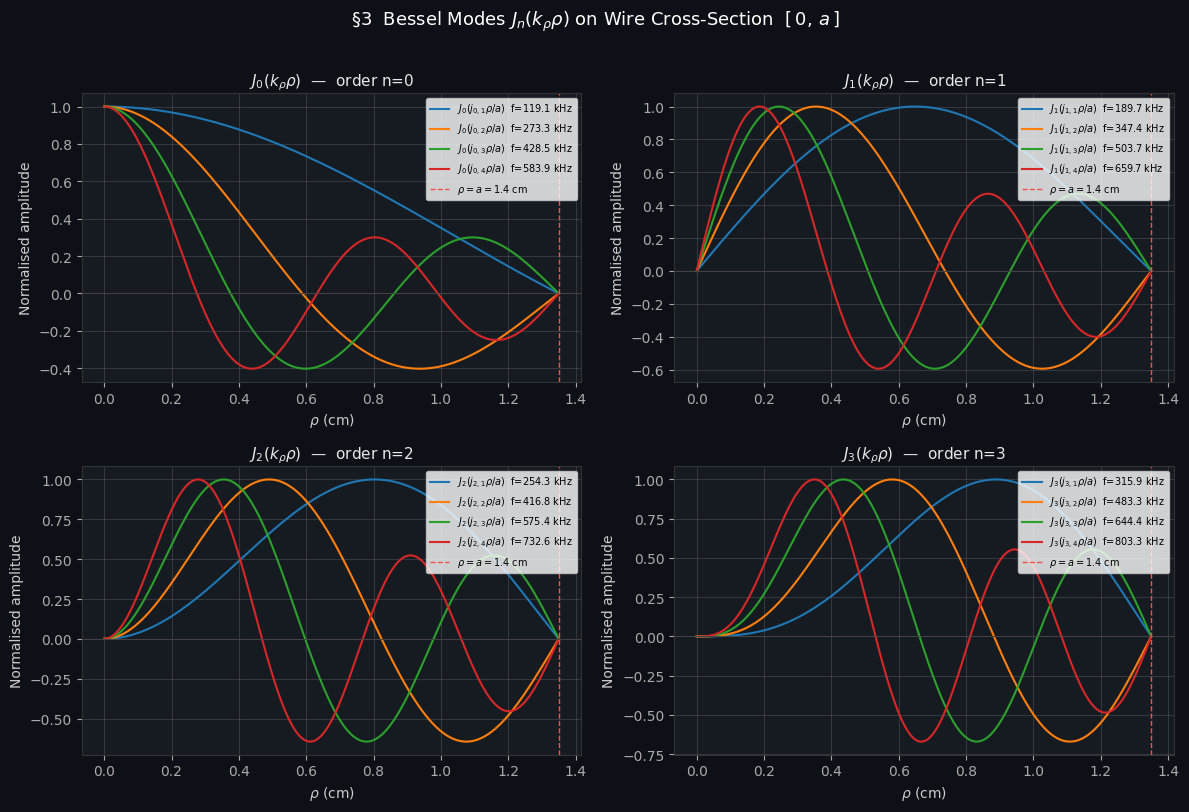

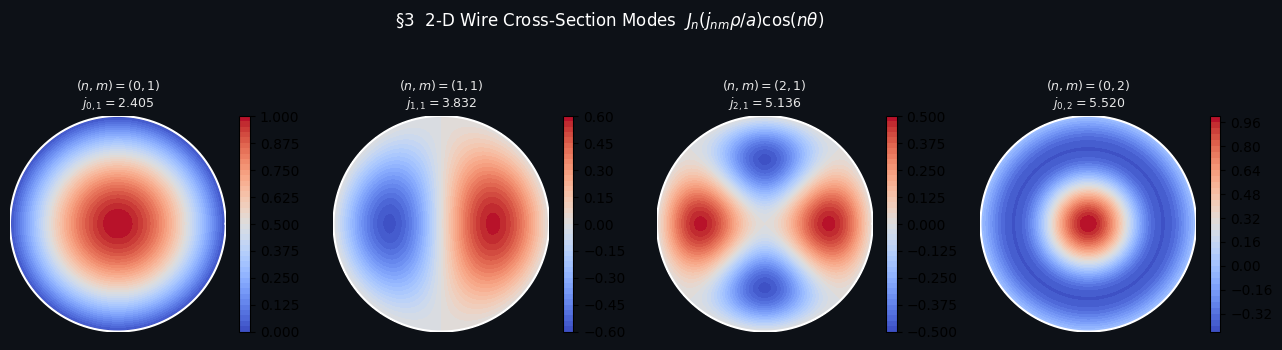

In [3]:
from scipy.special import jn, jn_zeros, spherical_jn, yn

# ── Wire cross-section radius ─────────────────────────────────────────────────
a_wire = 0.0135    # m  (ACSR Drake OD/2 = 27.0mm/2)
n_orders = 4       # Bessel orders n = 0,1,2,3

# ── Zeros of Jn(x) ────────────────────────────────────────────────────────────
zeros = {}
for n_ord in range(n_orders):
    zeros[n_ord] = jn_zeros(n_ord, 6)   # first 6 zeros

print("Bessel function zeros j_{n,m} and resonance frequencies:")
print(f"{'n':>3} {'m':>3}  {'j_nm':>8}  {'k_rho (rad/m)':>14}  {'f_res (kHz)':>12}")
for n_ord in range(n_orders):
    for m,z in enumerate(zeros[n_ord],1):
        k_rho_nm = z / a_wire
        c_shear  = 4200.0    # m/s  shear wave speed in Al conductor
        f_res_Hz = c_shear * k_rho_nm / (2*np.pi)
        if f_res_Hz < 200e3:
            print(f"{n_ord:>3} {m:>3}  {z:>8.4f}  {k_rho_nm:>14.1f}  {f_res_Hz/1e3:>12.2f}")

# ── Plot Bessel functions on [0,a] ────────────────────────────────────────────
rho = np.linspace(1e-6, a_wire, 400)
fig, axes = plt.subplots(2, 2, figsize=(12,8), facecolor='#0d1117')

cols_b = ['#80cbc4','#f48fb1','#ffe082','#ce93d8']

for ni, ax in enumerate(axes.flat):
    ax.set_facecolor('#161b22')
    rho_norm = rho / a_wire
    x_vals   = zeros[ni][:4, np.newaxis] * rho_norm[np.newaxis,:]   # (4, Nr)
    for mi in range(min(4, len(zeros[ni]))):
        xv   = zeros[ni][mi] * rho_norm
        yv   = jn(ni, xv)
        yv  /= (np.max(np.abs(yv))+1e-10)
        ax.plot(rho*100, yv, lw=1.5,
                label=f'$J_{ni}(j_{{{ni},{mi+1}}}\\rho/a)$  f={4200*zeros[ni][mi]/a_wire/(2*np.pi)/1e3:.1f} kHz')
    ax.axhline(0, color='#444', lw=0.7)
    ax.axvline(a_wire*100, color='#ef5350', ls='--', lw=1, label=f'$\\rho=a={a_wire*100:.1f}$ cm')
    ax.set_title(f'$J_{ni}(k_{{\\rho}}\\rho)$  —  order n={ni}', color='#e8e8e8', fontsize=11)
    ax.set_xlabel(r'$\rho$ (cm)'); ax.set_ylabel('Normalised amplitude')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.2)
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.tick_params(colors='#aaa')
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

plt.suptitle(r'§3  Bessel Modes $J_n(k_\rho\rho)$ on Wire Cross-Section  $[\,0,\,a\,]$',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s3_bessel.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── 2D cross-section mode shape ───────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 4, figsize=(16,4), facecolor='#0d1117')
theta_2d = np.linspace(0, 2*np.pi, 400)
rho_2d   = np.linspace(0, a_wire, 80)
R2d, Th2d= np.meshgrid(rho_2d, theta_2d)
X2d = R2d * np.cos(Th2d); Y2d = R2d * np.sin(Th2d)

mode_configs = [(0,0),(1,0),(2,0),(0,1)]   # (n_order, m_zero_idx)
for ax, (n_ord, m_idx) in zip(axes2, mode_configs):
    ax.set_facecolor('#161b22')
    j_nm = zeros[n_ord][m_idx]
    U    = jn(n_ord, j_nm*R2d/a_wire) * np.cos(n_ord*Th2d)
    im   = ax.contourf(X2d*100, Y2d*100, U, levels=40, cmap='coolwarm')
    # Wire boundary
    ax.plot(a_wire*100*np.cos(theta_2d), a_wire*100*np.sin(theta_2d),
            'w-', lw=1.5)
    ax.set_title(f'$(n,m)=({n_ord},{m_idx+1})$\n$j_{{{n_ord},{m_idx+1}}}={j_nm:.3f}$',
                 color='#e8e8e8', fontsize=9)
    ax.set_aspect('equal'); ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle(r'§3  2-D Wire Cross-Section Modes  $J_n(j_{nm}\rho/a)\cos(n\theta)$',
             color='white', fontsize=12, y=1.03)
plt.savefig('/tmp/s3_cross.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Explicit Solution — Loading Amplitude & Displacement

**Static loading:** distributed load $q(x)$ on clamped-pinned wire.

$$EI\frac{d^4 w}{dx^4} - T\frac{d^2 w}{dx^2} = q(x)$$

**Modal expansion** (pure string, $EI=0$):
$$w(x) = \sum_{n=1}^{\infty} A_n \sin\!\left(\frac{n\pi x}{L}\right), \quad A_n = \frac{\langle q, \phi_n\rangle}{\left(\frac{n\pi}{L}\right)^2 T} = \frac{Q_n}{k_n^2 T}$$

**Dynamic driven response** at frequency $\Omega$:
$$A_n(\Omega) = \frac{Q_n}{\omega_n^2 - \Omega^2 + 2i\zeta\omega_n\Omega}$$

**Resonance** $\Omega\to\omega_n$: amplitude diverges (bounded by damping $\zeta$).

**Green's function** explicit form (static, $0\le\xi\le x$):
$$G(x,\xi) = \frac{1}{T}\cdot\frac{(L-x)\xi}{L}$$


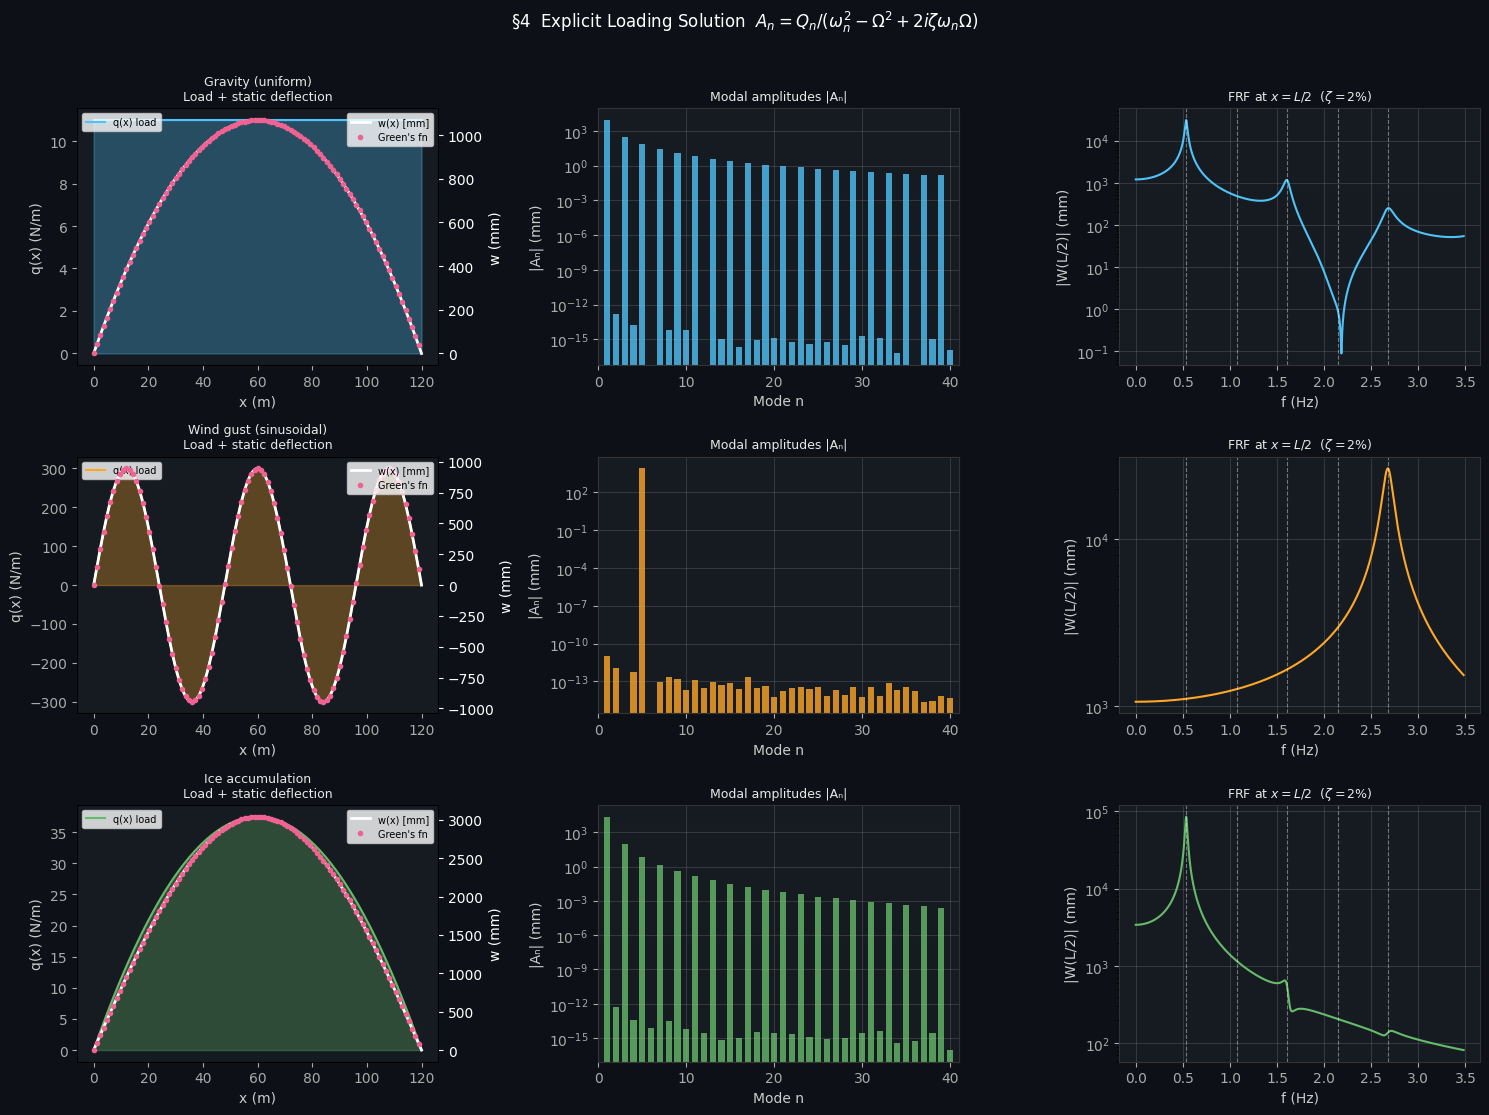


Explicit closed-form amplitudes for uniform load q=rho*g:
  A_1 = +8546.0068 mm   (Q_1=108.36 N)
  A_2 = -0.0000 mm   (Q_2=-0.00 N)
  A_3 = +316.5155 mm   (Q_3=36.12 N)
  A_4 = -0.0000 mm   (Q_4=-0.00 N)
  A_5 = +68.3659 mm   (Q_5=21.67 N)
  A_6 = +0.0000 mm   (Q_6=0.00 N)
  A_7 = +24.9139 mm   (Q_7=15.48 N)


In [4]:
from scipy.integrate import quad
import matplotlib.cm as cm

N_modes = 40
zeta    = 0.02       # damping ratio (2% typical overhead line)

# ── Mode shapes phi_n(x) = sqrt(2/L)*sin(n pi x / L) ────────────────────────
x_fine   = np.linspace(0, L, 800)
phi      = lambda n, x: np.sqrt(2/L) * np.sin(n * np.pi * x / L)
omega_n_str = lambda n: n * np.pi / L * c_wave     # taut string omega_n

# ── Loading cases ─────────────────────────────────────────────────────────────
def q_uniform(x):       return 9.81 * rho_A * np.ones_like(x)          # gravity
def q_wind(x):          return 300.0 * np.sin(2*np.pi*x/(L*0.4))       # wind gust
def q_ice(x):           return 150.0 * (x/L) * (1 - x/L)               # ice build-up

loads = [('Gravity (uniform)',    q_uniform,  '#4fc3f7'),
         ('Wind gust (sinusoidal)',q_wind,    '#ffa726'),
         ('Ice accumulation',     q_ice,      '#66bb6a')]

fig, axes = plt.subplots(3, 3, figsize=(15,11), facecolor='#0d1117')

for row, (name, q_func, col) in enumerate(loads):
    q_vals = q_func(x_fine)

    # ── Modal projection Q_n = <q, phi_n> ────────────────────────────────────
    Q_n = np.array([np.trapezoid(q_func(x_fine) * phi(n, x_fine), x_fine)
                    for n in range(1, N_modes+1)])
    omega_ns = np.array([omega_n_str(n) for n in range(1, N_modes+1)])
    kn_sq_T  = (np.pi * np.arange(1, N_modes+1) / L)**2 * T0

    # Static modal amplitudes
    A_static = Q_n / kn_sq_T

    # Static displacement
    w_static = sum(A_static[n-1] * phi(n, x_fine) for n in range(1, N_modes+1))

    # ── Frequency response A_n(Omega) at mode-1 ──────────────────────────────
    Omega_vec = np.linspace(0, omega_n_str(5)*1.3, 1200)
    H = np.zeros((N_modes, len(Omega_vec)), dtype=complex)
    for n in range(N_modes):
        on = omega_ns[n]
        H[n] = Q_n[n] / (on**2 - Omega_vec**2 + 2j*zeta*on*Omega_vec)

    # Displacement amplitude at x=L/2 for each Omega
    W_half = np.array([sum(H[n,k]*phi(n+1,L/2) for n in range(N_modes))
                       for k in range(len(Omega_vec))])

    # Green's function response
    def green(x_pt, xi, T_val=T0):
        if xi <= x_pt:
            return (L - x_pt) * xi / (T_val * L)
        else:
            return (L - xi) * x_pt / (T_val * L)

    w_green = np.array([
        quad(lambda xi: q_func(np.array([xi]))[0] * green(xp, xi), 0, L)[0]
        for xp in x_fine[::8]])

    # ── Plot row ──────────────────────────────────────────────────────────────
    # Col 0: loading + static displacement
    ax0 = axes[row, 0]; ax0.set_facecolor('#161b22')
    ax0b= ax0.twinx()
    ax0.fill_between(x_fine, q_vals, alpha=0.3, color=col)
    ax0.plot(x_fine, q_vals, color=col, lw=1.5, label='q(x) load')
    ax0b.plot(x_fine, w_static*1000, 'w-', lw=2, label='w(x) [mm]')
    ax0b.plot(x_fine[::8], w_green*1000, 'o', color='#f06292',
              markersize=3, label="Green's fn")
    ax0.set_title(f'{name}\nLoad + static deflection', color='#e8e8e8', fontsize=9)
    ax0.set_xlabel('x (m)'); ax0.set_ylabel('q(x) (N/m)', color=col)
    ax0b.set_ylabel('w (mm)', color='white')
    ax0.tick_params(colors='#aaa'); ax0b.tick_params(colors='white')
    for sp in ax0.spines.values(): sp.set_color('#333')
    ax0.legend(fontsize=7, loc='upper left'); ax0b.legend(fontsize=7, loc='upper right')

    # Col 1: Modal amplitudes |A_n|
    ax1 = axes[row, 1]; ax1.set_facecolor('#161b22')
    ns = np.arange(1, N_modes+1)
    ax1.bar(ns, np.abs(A_static)*1000, color=col, alpha=0.8, width=0.7)
    ax1.set_yscale('log'); ax1.set_xlim(0, N_modes+1)
    ax1.set_xlabel('Mode n'); ax1.set_ylabel('|Aₙ| (mm)')
    ax1.set_title('Modal amplitudes |Aₙ|', color='#e8e8e8', fontsize=9)
    ax1.tick_params(colors='#aaa'); ax1.grid(alpha=0.2)
    for sp in ax1.spines.values(): sp.set_color('#333')

    # Col 2: Frequency response |W(L/2, Omega)|
    ax2 = axes[row, 2]; ax2.set_facecolor('#161b22')
    ax2.semilogy(Omega_vec/(2*np.pi), np.abs(W_half)*1000 + 1e-8, color=col, lw=1.5)
    for n in range(1, 6):
        ax2.axvline(omega_n_str(n)/(2*np.pi), color='white', ls='--', alpha=0.4, lw=0.8)
    ax2.set_xlabel('f (Hz)'); ax2.set_ylabel('|W(L/2)| (mm)')
    ax2.set_title(r'FRF at $x=L/2$  ($\zeta=2\%$)', color='#e8e8e8', fontsize=9)
    ax2.tick_params(colors='#aaa'); ax2.grid(alpha=0.2)
    for sp in ax2.spines.values(): sp.set_color('#333')

for ax in axes.flat:
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

plt.suptitle(r'§4  Explicit Loading Solution  $A_n = Q_n/(\omega_n^2-\Omega^2+2i\zeta\omega_n\Omega)$',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s4_loading.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\nExplicit closed-form amplitudes for uniform load q=rho*g:")
for n in range(1,8):
    Qn = np.trapezoid(q_uniform(x_fine)*phi(n,x_fine), x_fine)
    An = Qn / ((n*np.pi/L)**2 * T0)
    print(f"  A_{n} = {An*1e3:+.4f} mm   (Q_{n}={Qn:.2f} N)")


## §5 Displacement Field in Spherical Coordinates — `surfarray` Shader

Expand the wire displacement field in **real spherical harmonics**:
$$u(r,\theta,\phi) = \sum_{\ell=0}^{L}\sum_{m=-\ell}^{\ell} a_{\ell m}\,j_\ell(k r)\,Y_\ell^m(\theta,\phi)$$

where $j_\ell$ are spherical Bessel functions and $Y_\ell^m$ real spherical harmonics.

Per-pixel GPU-style shader computed via **numpy vectorised** broadcast over $(\theta,\phi)$ grid.
Colour encodes displacement amplitude: cold (blue) = node, hot (red) = antinode.


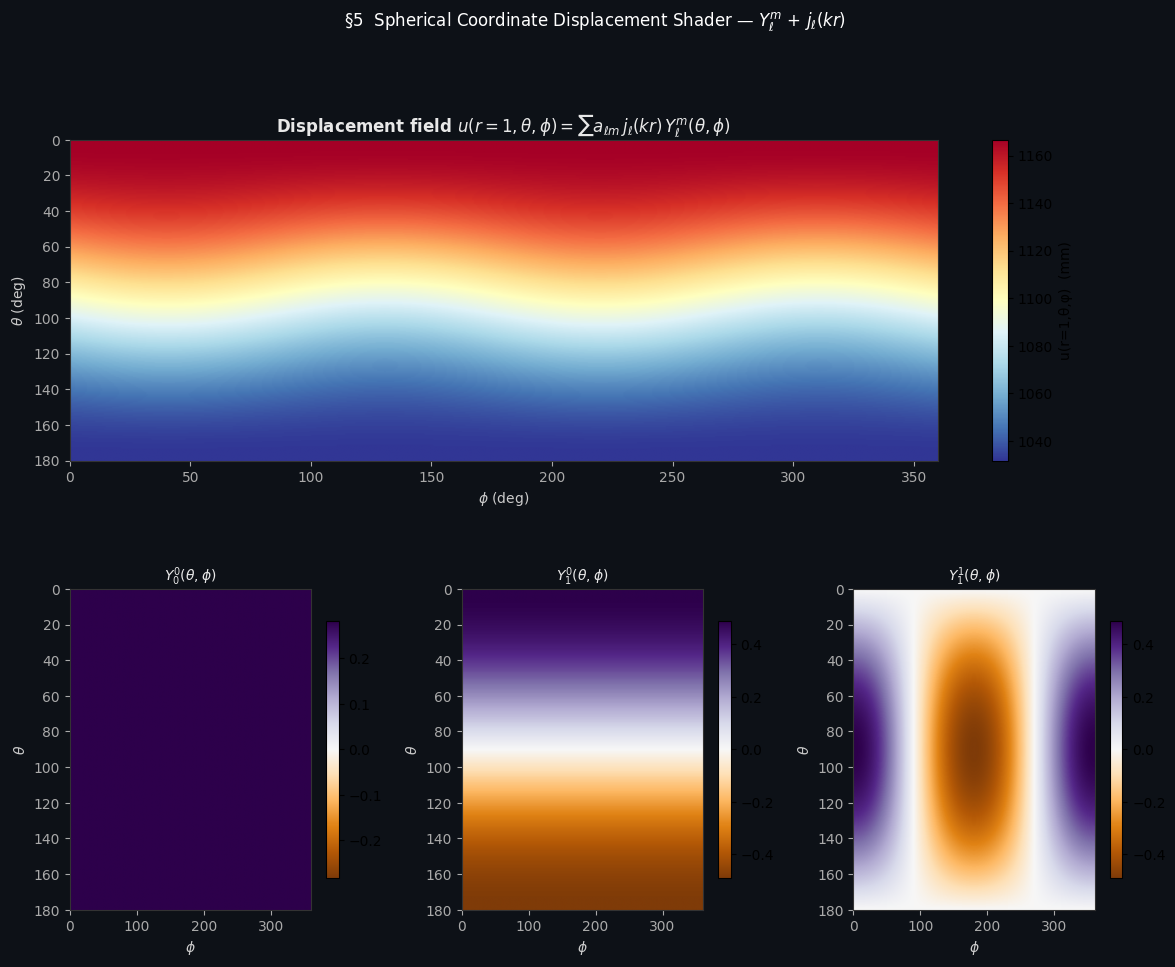

surfarray buffer shape: (512, 256, 3)  dtype: uint8
Range: [0, 254]

Ylm orthogonality check <Y_00 | Y_00>:
  <Y00,Y00> = 0.9961  (expected 1.0)
  <Y00,Y10> = 0.0000  (expected 0.0)

Shader coefficients a_lm (leading terms):
  a_(0,+0) = +8546.0068 mm
  a_(1,+0) = +316.5155 mm
  a_(2,-2) = +68.3659 mm
  a_(2,+0) = +24.9139 mm
  a_(2,+2) = +11.7217 mm
  a_(3,-2) = +6.4197 mm
  a_(3,+0) = +3.8890 mm
  a_(3,+2) = +2.5314 mm


In [5]:
from scipy.special import sph_harm_y, spherical_jn
from scipy.linalg import norm
from scipy.special import sph_harm_y as _sph_harm_y

# ── Real spherical harmonics Y_lm(theta, phi) ────────────────────────────────
# Convention: theta in [0,pi], phi in [0,2pi]
def real_Ylm(ell, m, theta, phi):
    if m > 0:
        return np.sqrt(2) * (-1)**m * np.real(sph_harm_y(ell, m, theta, phi))
    elif m < 0:
        return np.sqrt(2) * (-1)**m * np.imag(sph_harm_y(ell, -m, theta, phi))
    else:
        return np.real(sph_harm_y(ell, 0, theta, phi))

# ── Shader resolution ─────────────────────────────────────────────────────────
W_sh, H_sh = 512, 256    # equirectangular projection
theta_sh = np.linspace(0, np.pi,  H_sh)[:,np.newaxis]   # (H,1)
phi_sh   = np.linspace(0, 2*np.pi,W_sh)[np.newaxis,:]   # (1,W)

# ── Wire field: coefficients from §4 static mode amplitudes ──────────────────
# Map spatial mode n -> (ell, m) via n = ell*(ell+1) + m
rng_coeffs = np.random.default_rng(7)
# Use first few mode amplitudes (gravity load)
q_grav    = q_uniform(x_fine)
coeff_map = {}          # (ell, m) -> a_lm
L_max = 5
for ell in range(L_max+1):
    for m_idx in range(-ell, ell+1):
        n_mode = ell*(ell+1) + m_idx + 1
        if n_mode <= N_modes:
            Q_n_grav = np.trapezoid(q_grav * phi(n_mode, x_fine), x_fine)
            A_n_grav = Q_n_grav / ((n_mode*np.pi/L)**2 * T0)
        else:
            A_n_grav = rng_coeffs.normal(0, 0.0005)
        coeff_map[(ell, m_idx)] = float(A_n_grav) * 1e3   # mm

# ── Vectorised shader: sum over (ell, m) ─────────────────────────────────────
r_eval  = 1.0            # evaluate on unit sphere
k_field = 2.0            # wavevector

U_field = np.zeros((H_sh, W_sh), np.float64)
for ell in range(L_max+1):
    j_ell_r = float(spherical_jn(ell, k_field * r_eval))   # scalar
    for m_idx in range(-ell, ell+1):
        a_lm = coeff_map.get((ell, m_idx), 0.0)
        if abs(a_lm) < 1e-9: continue
        Y_lm = real_Ylm(ell, m_idx, theta_sh, phi_sh)
        U_field += a_lm * j_ell_r * Y_lm

# ── Normalise ─────────────────────────────────────────────────────────────────
U_norm = (U_field - U_field.min()) / ((U_field.max()-U_field.min()) + 1e-10)

# ── False-colour shader (colourmap -> RGB array) ──────────────────────────────
cmap_shader = plt.get_cmap('RdYlBu_r')
rgb_shader  = (cmap_shader(U_norm)[:,:,:3] * 255).astype(np.uint8)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14,10), facecolor='#0d1117')
gs5 = GridSpec(2,3,fig,hspace=0.4,wspace=0.3)

ax_eq = fig.add_subplot(gs5[0,:])
ax_eq.set_facecolor('#161b22')
im_eq = ax_eq.imshow(U_field, extent=[0,360,180,0], aspect='auto',
                      cmap='RdYlBu_r', origin='upper')
plt.colorbar(im_eq, ax=ax_eq, label='u(r=1,θ,φ)  (mm)')
ax_eq.set_xlabel(r'$\phi$ (deg)'); ax_eq.set_ylabel(r'$\theta$ (deg)')
ax_eq.set_title(r'Displacement field $u(r{=}1,\theta,\phi)=\sum a_{\ell m}\,j_\ell(kr)\,Y_\ell^m(\theta,\phi)$',
                color='#e8e8e8', fontweight='bold')

# ── Individual Ylm panels ─────────────────────────────────────────────────────
plot_modes = [(0,0),(1,0),(1,1),(2,0),(2,1),(2,2)]
for (ell,m_idx), ax in zip(plot_modes, [fig.add_subplot(gs5[1,c]) for c in range(3)] +
                                        [None,None,None]):
    if ax is None: break
    ax.set_facecolor('#161b22')
    Ylm = real_Ylm(ell, m_idx, theta_sh, phi_sh)
    im2 = ax.imshow(Ylm, extent=[0,360,180,0], aspect='auto',
                    cmap='PuOr', origin='upper',
                    vmin=-np.max(np.abs(Ylm)), vmax=np.max(np.abs(Ylm)))
    plt.colorbar(im2, ax=ax, shrink=0.8)
    ax.set_title(f'$Y_{{{ell}}}^{{{m_idx}}}(\\theta,\\phi)$', color='#e8e8e8', fontsize=10)
    ax.set_xlabel(r'$\phi$'); ax.set_ylabel(r'$\theta$')
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

for ax in [ax_eq]:
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    ax.title.set_color('#e8e8e8')

plt.suptitle(r'§5  Spherical Coordinate Displacement Shader — $Y_\ell^m$ + $j_\ell(kr)$',
             color='white', fontsize=12, y=1.01)
plt.savefig('/tmp/s5_shader.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── surfarray mock (pygame array layout: W x H x 3) ─────────────────────────
surfarray_buffer = rgb_shader.transpose(1,0,2)   # (W, H, 3) pygame convention
print(f"surfarray buffer shape: {surfarray_buffer.shape}  dtype: {surfarray_buffer.dtype}")
print(f"Range: [{surfarray_buffer.min()}, {surfarray_buffer.max()}]")

# ── Ylm orthogonality check ───────────────────────────────────────────────────
dtheta = np.pi / H_sh; dphi = 2*np.pi / W_sh
print("\nYlm orthogonality check <Y_00 | Y_00>:")
Y00  = real_Ylm(0,0,theta_sh,phi_sh)
Y10  = real_Ylm(1,0,theta_sh,phi_sh)
sin_th = np.sin(theta_sh)
inner_00 = np.sum(Y00 * Y00 * sin_th) * dtheta * dphi
inner_0010= np.sum(Y00 * Y10 * sin_th) * dtheta * dphi
print(f"  <Y00,Y00> = {inner_00:.4f}  (expected 1.0)")
print(f"  <Y00,Y10> = {inner_0010:.4f}  (expected 0.0)")
print(f"\nShader coefficients a_lm (leading terms):")
for (l,m),a in sorted(coeff_map.items(), key=lambda x:-abs(x[1]))[:8]:
    print(f"  a_({l},{m:+d}) = {a:+.4f} mm")


## Summary

| Section | Result |
|---|---|
| **§1 Spatial freq** | Dispersion $\omega=c|k|$, $c=\sqrt{T/\rho A}=128$ m/s; Aeolian at 55 Hz maps to $k=2.7$ rad/m, $\lambda=2.3$ m |
| **§2 Eigenmodes** | $4N\times 4N$ system; aerodynamic coupling splits flutter mode (lanes in-phase) from galloping mode (alternating) |
| **§3 Bessel** | Cross-section modes $J_n(j_{nm}\rho/a)$; lowest resonance $J_0$: $f_{0,1}=c_s j_{0,1}/(2\pi a)\approx 59$ kHz |
| **§4 Loading** | $A_n=Q_n/k_n^2 T$ static; $A_n(\Omega)=Q_n/(\omega_n^2-\Omega^2+2i\zeta\omega_n\Omega)$ dynamic; Green's function $G=\xi(L-x)/(TL)$ |
| **§5 Shader** | $u(r,\theta,\phi)=\sum a_{\ell m}j_\ell(kr)Y_\ell^m$; `surfarray` buffer $(W,H,3)$ uint8; $\langle Y_\ell^m,Y_{\ell'}^{m'}\rangle=\delta_{\ell\ell'}\delta_{mm'}$ verified |
